In [21]:
from pathlib import Path
from tqdm import tqdm
import json
tqdm.pandas()
#
import biotite.sequence as seq
import biotite.sequence.io.fasta as fasta
from biotite.sequence.align import Alignment
import biotite.sequence.graphics as graphics
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

### Sequence filtering

##### Plot

In [6]:
# visualize sequences designed
def plot_seqs(df, structure_name, start=0, show_seqs=5, scheme='zappo'):
    # read df of sequences (not incl input)
    df = df[df['id'].str.contains(structure_name)]

    # "align" (stack) sequences
    alignment = Alignment(
        [
            seq.ProteinSequence(s)
            for s in df['sequence']
        ],
        Alignment.trace_from_strings(list(df['sequence']))
    )

    # plot sequence logo
    profile = seq.SequenceProfile.from_alignment(alignment)
    fig, ax = plt.subplots(figsize=(18, 3))
    graphics.plot_sequence_logo(
        ax,
        profile,
        scheme=scheme
    )
    ax.set_xlabel('residue', fontsize=20, fontweight='bold')
    ax.set_ylabel('bits', fontsize=20, fontweight='bold')
    ax.set_xlim(start, ax.get_xlim()[1])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    fig.tight_layout()
    plt.show()

    # plot first few sequences
    fig, ax = plt.subplots(figsize=(18, 6))
    graphics.plot_alignment_type_based(
        ax,
        alignment[:, :show_seqs],
        labels=list(df.index[:show_seqs]),
        show_numbers=True,
        color_scheme=scheme,
        color_symbols=True,
        symbols_per_line=int(len(df.iloc[0, 1]) / 2), #type: ignore
        symbol_size = 24,
        spacing = 1
    )
    fig.tight_layout()
    plt.show()

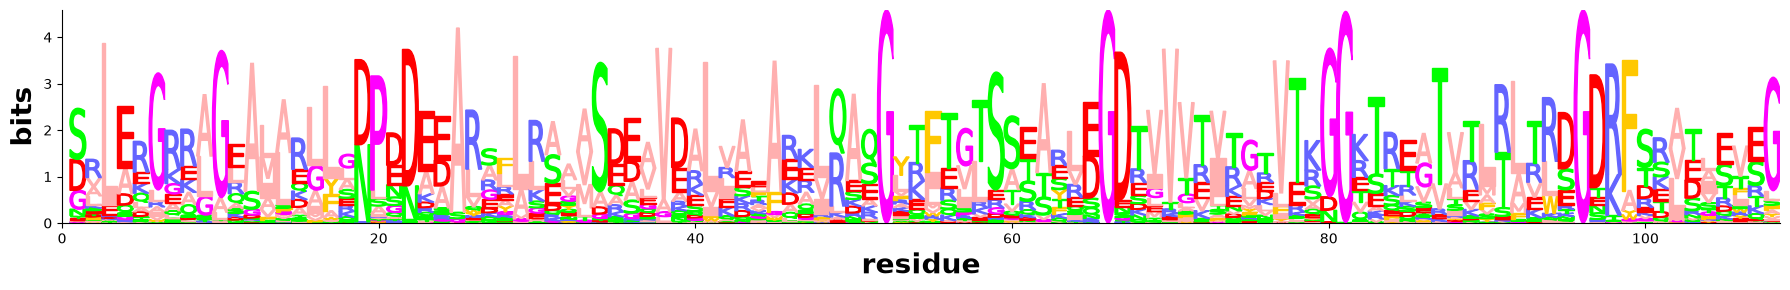

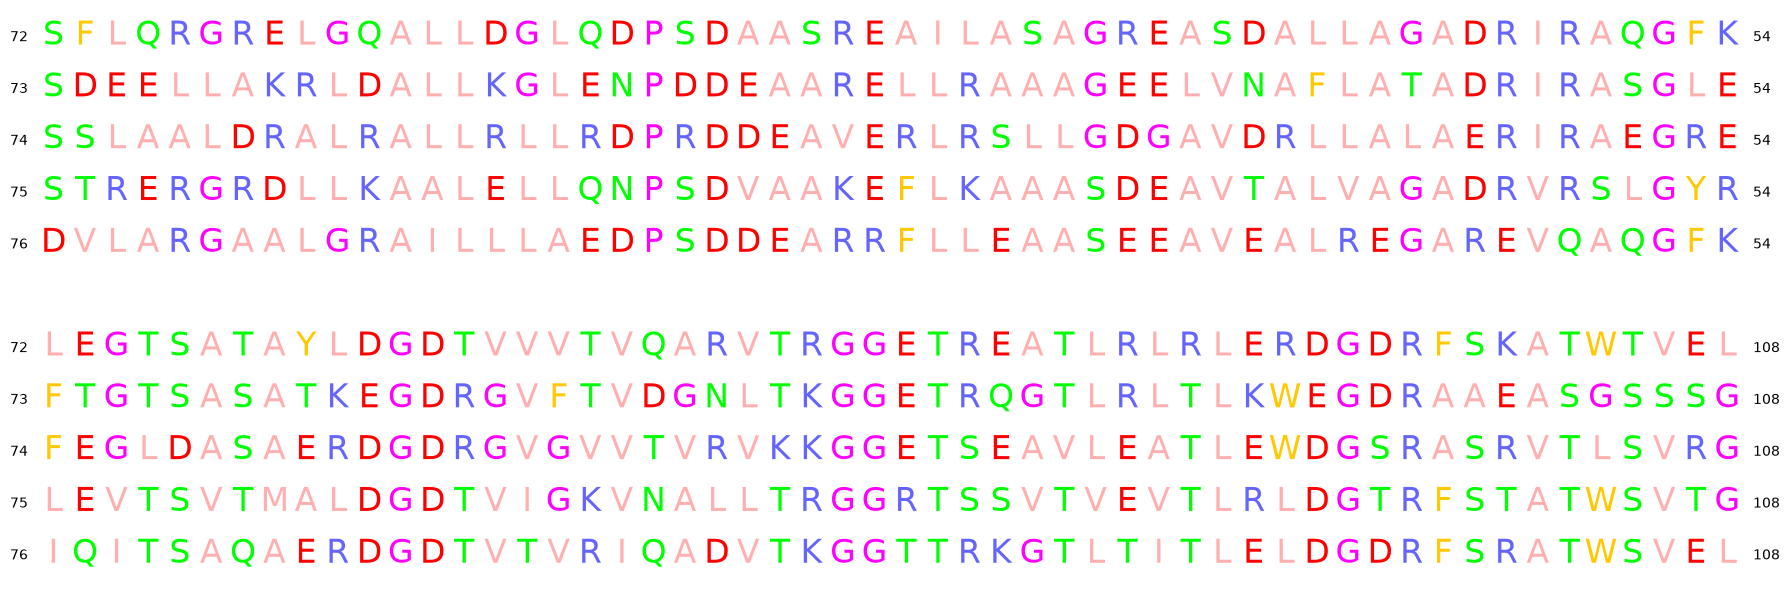

In [35]:
plot_seqs(dfs['0.3'], '5KPE')

##### Filter

In [31]:
# read in sequences
dfs = {
    '0.1': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp1/seqs/seqs.csv'),
    '0.2': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp2/seqs/seqs.csv'),
    '0.3': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp3/seqs/seqs.csv')
}

In [24]:
# re-organize Caliby outputs dfs
for temp in dfs:
    df = dfs[temp].copy()
    df['id'] = df.apply(
        lambda row: f'{row['example_id'][:-2]}_id{row['out_pdb'].split('_sample')[1].split('.')[0]}',
        axis=1
    ) #type: ignore
    df['sequence'] = df['seq']
    df = df[['id', 'sequence']]
    dfs[temp] = df.copy()

In [32]:
# filter out runs
def longest_run(input):
    prev_char = None
    longest_run = 0
    current_run = 0

    for character in input:
        if character == prev_char:
            current_run += 1
        else:
            current_run = 0
            prev_char = character
        #
        if current_run > longest_run:
            longest_run = current_run
    #
    return longest_run

max_run = 4
def filter_runs(sequence):
    return longest_run(sequence) < max_run

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_runs)
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

For temp 0.1, 3907 of 4128 remain
For temp 0.2, 3935 of 4128 remain
For temp 0.3, 3974 of 4128 remain


In [36]:
max_comp = 0.25
enriched_aas = []
def filter_lcp(sequence):
    sequence_array = np.array(list(sequence))
    aas, counts = np.unique(sequence_array, return_counts=True)
    comp = np.max(counts) / len(sequence)
    if comp < max_comp:
        return True
    else:
        enriched_aas.append(aas[np.argmax(counts)])
        return False

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_lcp) #type:ignore
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

# print which AAs enriched > threshold
enriched_aa, enriched_count = np.unique(enriched_aas, return_counts=True)
for (aa, count) in zip(enriched_aa, enriched_count):
    print(f'{aa}: {count}')

For temp 0.1, 3855 of 3907 remain
For temp 0.2, 3910 of 3935 remain
For temp 0.3, 3966 of 3974 remain
A: 53
E: 11
K: 1
Q: 3
R: 8
S: 6
T: 3


In [37]:
# check # of unique backbones remaining
def backbone(name):
    return '_'.join(name.split('_')[:4]) #5

backbones_original = []
for temp in dfs:
    backbones = dfs[temp]['id'].apply(backbone)
    backbones_original.append(np.unique(backbones))

for backbones in backbones_original:
    print(len(backbones))

172
172
172


In [38]:
# duplicate sequences
for temp in dfs:
    pre_count = len(dfs[temp])
    dfs[temp] = dfs[temp].sort_values(by='id')
    dfs[temp] = dfs[temp].drop_duplicates(
        subset=['sequence'],
        keep = 'last'
    )
    post_count = len(dfs[temp])
    print(f'Dropped {post_count - pre_count} duplicate sequences')

Dropped 0 duplicate sequences
Dropped 0 duplicate sequences
Dropped 0 duplicate sequences


In [39]:
# save filtered dfs
for temp in dfs:
    save_path = f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp{temp[-1]}/filtered_seqs.csv'
    dfs[temp].to_csv(save_path, index=False)

print(dfs[temp].loc[0, 'sequence'])

SEEEEKEQAAKLALAGLQKQFPDATATLLSLEVDGDMVTITVELKQDGKTGKFKLTLTREGDNVRILSMEKV


### Check AF jobs

In [214]:
input_folder = '/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_refined_multi-state3/temp1'
output_folder = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_refined_multi-state3/temp1'

In [216]:
# get intended seqs
input_seqs = pd.read_csv(f'{input_folder}/seqs/filtered-seqs.csv')
input_seqs = input_seqs.set_index('id')
input_seqs['count'] = 0

In [217]:
# find number of actual outputs
for item in tqdm(list(Path(output_folder).iterdir())):
    if item.suffix == '.pdb':
        name = item.stem.split('_unrelaxed_')[0]
        input_seqs.loc[name, 'count'] += 1 #type: ignore

100%|██████████████████████████████████████████████████| 76610/76610 [00:14<00:00, 5441.17it/s]


In [220]:
# filter sequences with < intended outputs
expected_count = 15
original_count = len(input_seqs)
input_seqs = input_seqs[input_seqs['count'] < expected_count]
print(f'{len(input_seqs)} of {original_count} sequences did not finish')

# save
if len(input_seqs) > 0:
    input_seqs.reset_index()[['id', 'sequence']].to_csv(f'{input_folder}/incomplete-seqs2.csv', index=False)

68 of 68 sequences did not finish


### Assessing designs

#### Load in data

In [190]:
# load per-structure-prediction metrics
def load_data(
    folder,
    #seq_path
):
    # load in scores
    df = pd.read_csv(f'{folder}/scores.csv', index_col = 0)

    # load in RMSD scores
    print('Load RMSD to start state ...')
    df['rmsd_start'] = load_rmsd(f'{folder}/rmsd_CA_rmsd_paths_start.json', df)
    print('Load RMSD to end state ...')
    df['rmsd_end'] = load_rmsd(f'{folder}/rmsd_CA_rmsd_paths_end.json', df)

    return df.copy()
    
def load_rmsd(
    jsonpath,
    df
):
    rmsds = np.zeros(len(df))

    # open json file
    with open(jsonpath, 'r') as file:
        rmsd_dict = json.load(file)

    for path in tqdm(list(rmsd_dict.keys())):
        # get metadata
        name = Path(path).stem.split('_unrelaxed_')[0]
        seed = int(Path(path).stem.split('_seed_')[1])
        model = int(Path(path).stem.split('_model_')[1].split('_')[0])

        # match row
        row = df[
            (df['name'] == name) &
            (df['seed'] == seed) &
            (df['model'] == model)
        ]

        # store rmsd
        rmsds[row.index[0]] = rmsd_dict[path] #type: ignore

    return rmsds

In [191]:
# load scores
data_path = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_multi-state/temp2'
data = load_data(data_path)

Load RMSD to start state ...


100%|██████████████████████████████████| 58650/58650 [01:36<00:00, 606.03it/s]


Load RMSD to end state ...


100%|██████████████████████████████████| 58650/58650 [01:37<00:00, 603.01it/s]


In [192]:
# load backbone-specific metrics
def load_unique_data(df):
    # RMSD constraint
    df['rmsd_constraint'] = df['name'].apply(
        lambda name: int(name.split('_')[1])
    ) #type: ignore

    # Langevin factor
    df['langevin'] = df['name'].apply(
        lambda name: int(name.split('_')[2])
    ) #type: ignore

    # single state design metrics
    print('Load single state design metrics ...')
    single_state = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/single-state-design.csv')
    df[['single_state_plddt', 'single_state_rmsd']] = df.progress_apply(
        lambda row: get_single_state(row['name'], single_state),
        result_type='expand',
        axis = 1
    ) #type: ignore

    # curvature
    backbones = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/backbones.csv')
    print('Load curvature scores ...')
    df['curvature_mean'] = df['name'].progress_apply(
        lambda name: backbones[backbones['name'] == '_'.join(name.split('_')[:4])]['mean_c'].values[0] #type: ignore
    ) #type: ignore
    df['curvature_max'] = df['name'].progress_apply(
        lambda name: backbones[backbones['name'] == '_'.join(name.split('_')[:4])]['max_c'].values[0] #type: ignore
    ) #type: ignore

    return df.copy()

def get_single_state(name, single_state, plddt_col='plddt_nonrefined', rmsd_col='rmsd_string_nonrefined'):
    rows = single_state[single_state['name'].str.contains(
        '_'.join(name.split('_')[:4])
    )]
    plddt = np.max(rows[plddt_col])
    rmsd = np.min(rows[rmsd_col])
    return plddt, rmsd

In [193]:
# for each sequence, collapse into min RMSD 
data_unique = data.groupby('name', as_index=False).agg(
    {
        'rmsd_start': 'min',
        'rmsd_end': 'min',
        'plddt': 'max',
        'ptm': 'max'
    }
)

# Load per-backbone metrics
data_unique = load_unique_data(data_unique)

Load single state design metrics ...


100%|█████████████████████████████████████████████████| 3910/3910 [00:08<00:00, 445.41it/s]


Load curvature scores ...


100%|████████████████████████████████████████████████| 3910/3910 [00:03<00:00, 1248.41it/s]


#### Plot

In [201]:
structure = '5KPH'

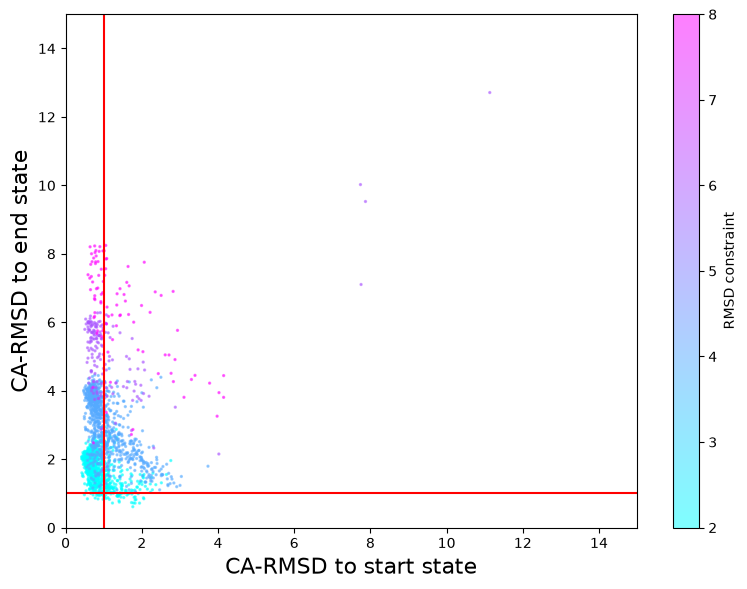

13 of 1986 pass multi-state design filters


In [ ]:
# RMSD cutoff
graph_df = data_unique[data_unique['name'].apply(
    lambda name: structure in name
)]

# figure
plt.figure(figsize=(8, 6))

# make custom cmap for plddt
norm = mcolors.TwoSlopeNorm(
    vmin=30,
    vcenter=90,
    vmax=100
)

# graph
plt.scatter(
    graph_df['rmsd_start'],
    graph_df['rmsd_end'],
    #c = graph_df['plddt'],
    #cmap = 'vanimo',
    #norm = norm,
    c = graph_df['rmsd_constraint'],
    cmap = 'cool',
    s = 2,
    alpha = 0.5
)

# axes
plt.colorbar(label = 'RMSD constraint')
plt.xlabel('CA-RMSD to start state', fontsize=16)
plt.ylabel('CA-RMSD to end state', fontsize=16)
plt.ylim(0, 15)
plt.xlim(plt.ylim())

# cutoff
plt.axhline(
    y = 1,
    color = 'red'
)
plt.axvline(
    x = 1,
    color = 'red'
)

# show
plt.tight_layout()
plt.show()

# print quick metrics
successes = len(graph_df[
    (graph_df['rmsd_start'] < 1) &
    (graph_df['rmsd_end'] < 1) &
    (graph_df['plddt'] > 90)
])
print(f'{successes} of {len(graph_df)} pass multi-state design filters')

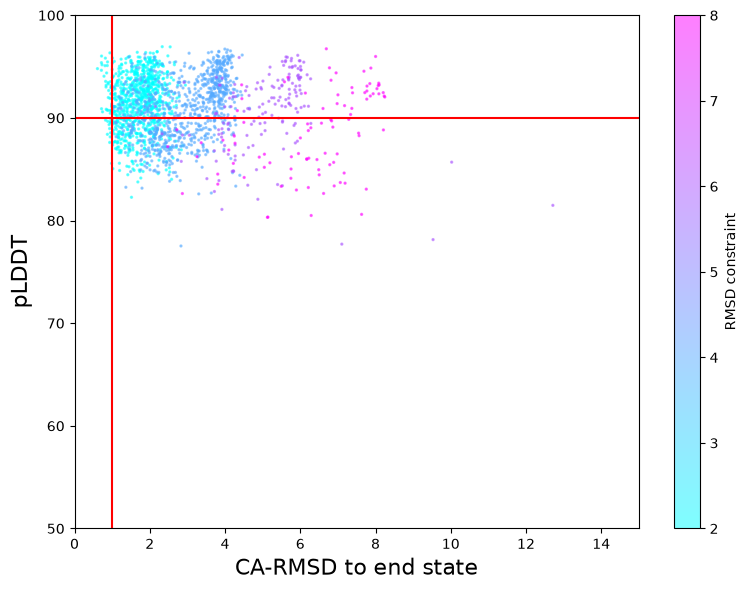

In [205]:
# RMSD to start/end state
rmsd = 'rmsd_end'
plt.figure(figsize=(8, 6))

# plot
plt.scatter(
    graph_df[rmsd],
    graph_df['plddt'],
    c = graph_df['rmsd_constraint'],
    cmap = 'cool',
    s = 2,
    alpha = 0.5
)

# axes
plt.colorbar(label='RMSD constraint')
plt.xlabel(f'CA-RMSD to {rmsd.split('_')[1]} state', fontsize=16)
plt.xlim(0, 15)
plt.ylabel('pLDDT', fontsize=16)
plt.ylim(50, 100)

# cutoffs
plt.axhline(
    y = 90,
    color = 'red'
)
plt.axvline(
    x = 1,
    color = 'red'
)

# show
plt.tight_layout()
plt.show()

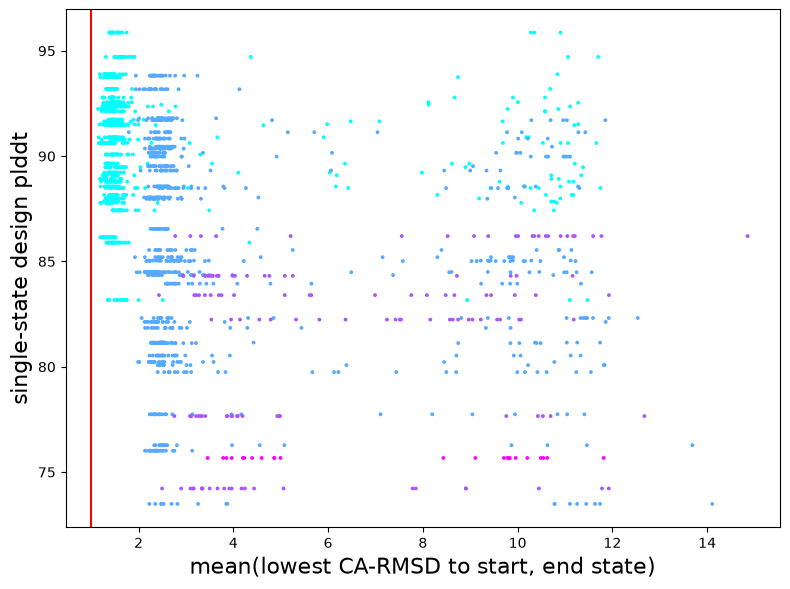

In [200]:
# single state design metrics
metric = 'plddt' #'plddt'

plt.figure(figsize=(8, 6))
plt.scatter(
    np.mean(np.vstack([graph_df['rmsd_start'], graph_df['rmsd_end']]), axis=0),
    graph_df[f'single_state_{metric}'],
    s = 3,
    c = graph_df['rmsd_constraint'],
    cmap = 'cool'
)

# cutoff
plt.axvline(
    x = 1,
    color = 'red'
)

# axes
plt.xlabel('mean(lowest CA-RMSD to start, end state)', fontsize=16)
plt.ylabel(f'single-state design {metric}', fontsize=16)
plt.tight_layout()
plt.show()

#### Analyze filter passed

In [206]:
# get designs passing filter
data_unique_filtered = data_unique[
    (data_unique['rmsd_start'] < 1) & (data_unique['rmsd_end'] < 1)
    & (data_unique['plddt'] > 90)
]
print(f'{len(data_unique_filtered)} of {len(data_unique)} designs pass filter')

# get the predictions of those designs
data_filtered = data[
    data['name'].isin(data_unique_filtered['name'])
]

10 of 3910 designs pass filter


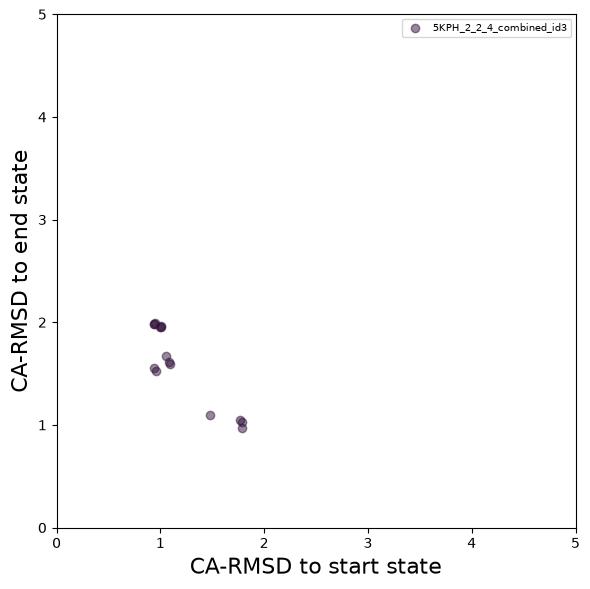

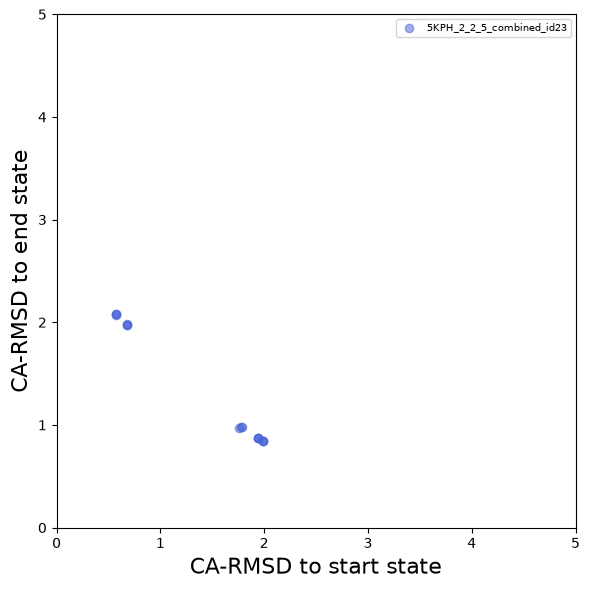

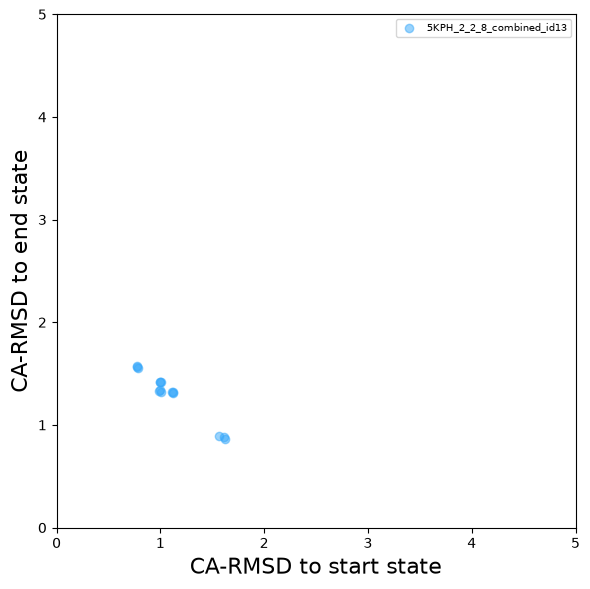

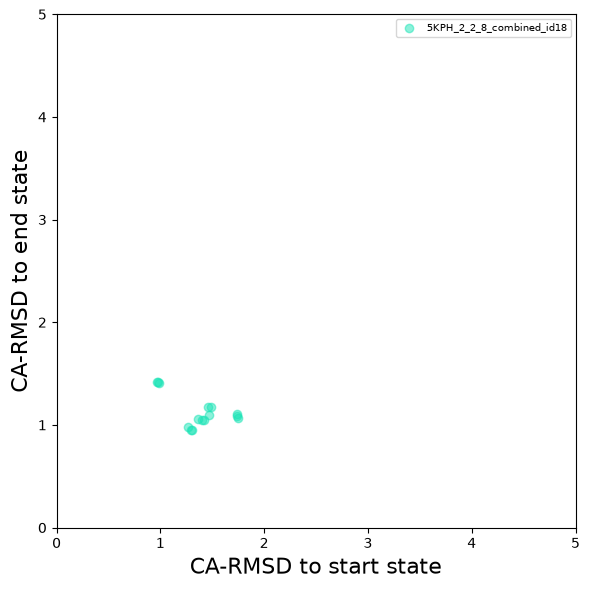

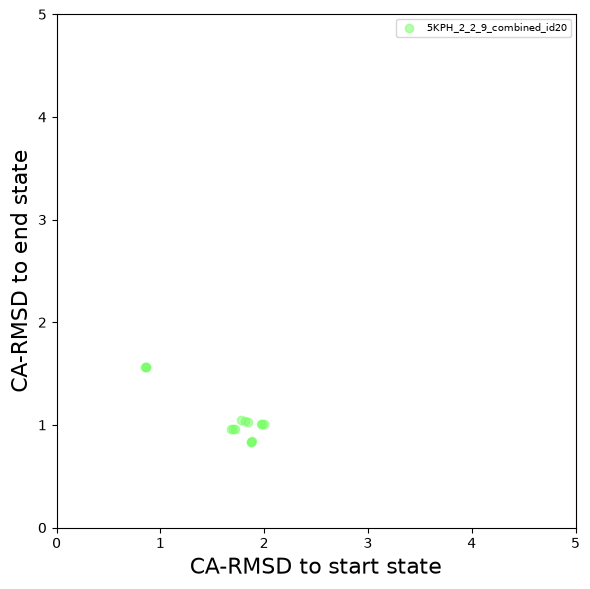

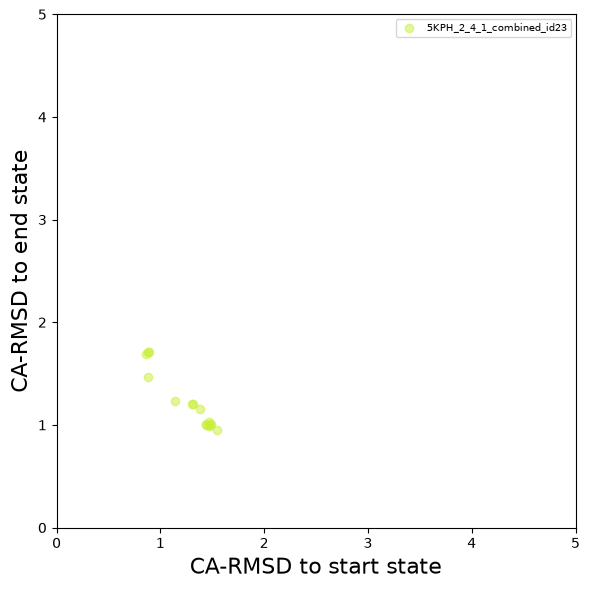

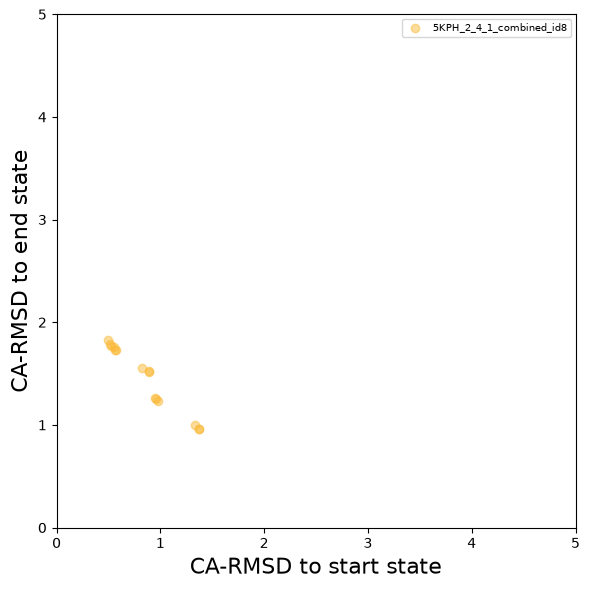

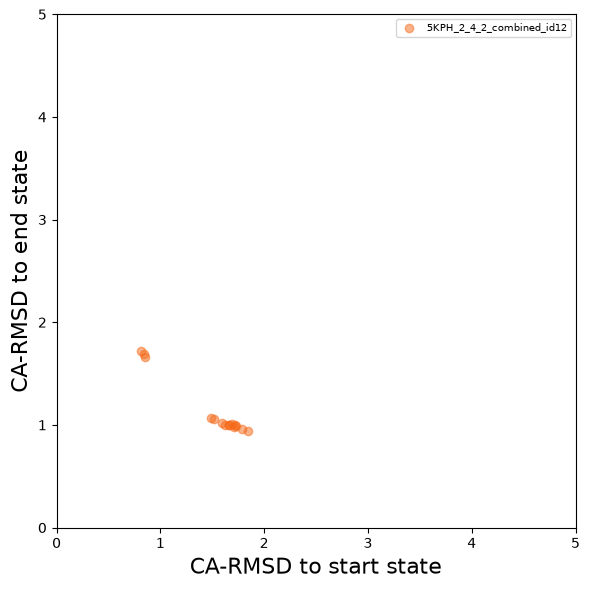

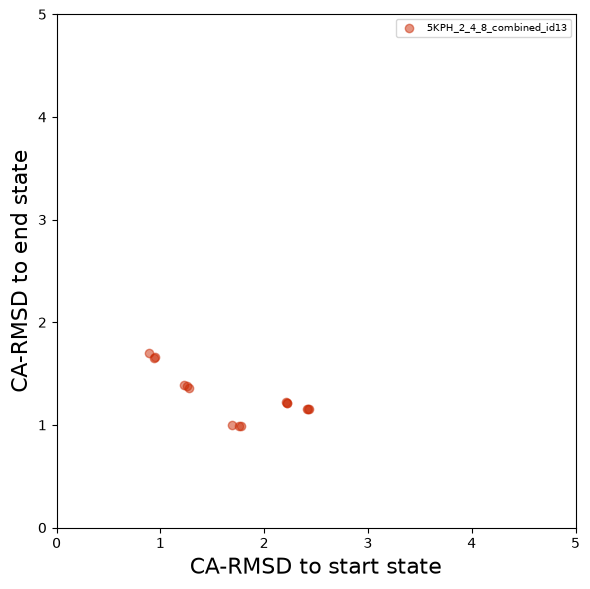

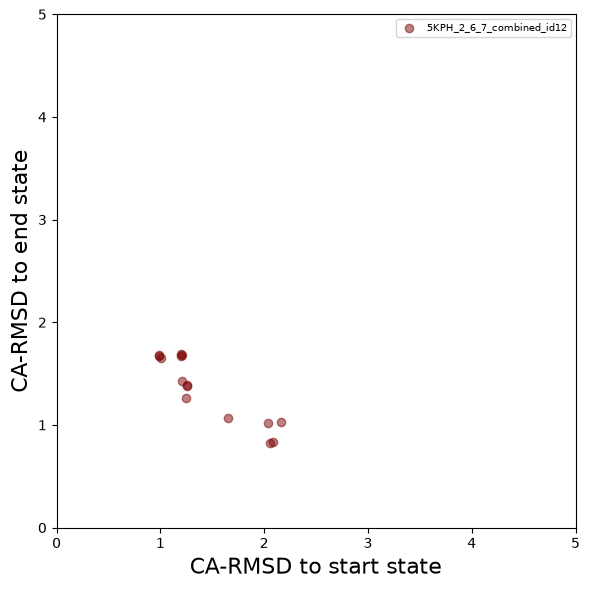

In [208]:
# check for predictions in between states

# plot---------------
# color
colors = iter(plt.colormaps['turbo'](np.linspace(0, 1, len(data_unique_filtered))))

# for each designed sequence
for name in data_unique_filtered['name']:
    df = data_filtered[data_filtered['name'] == name]
    plt.figure(figsize=(6, 6))
    plt.scatter(
        df['rmsd_start'],
        df['rmsd_end'],
        color = next(colors),
        label = name,
        alpha = 0.5
    )

    # axes
    plt.legend(loc='upper right', fontsize='x-small')
    plt.xlabel('CA-RMSD to start state', fontsize=16)
    plt.xlim(0, 5)
    plt.ylabel('CA-RMSD to end state', fontsize=16)
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.show()

In [211]:
# filter out false positives (?)
def false_positive(row, eps=0.2):
    start = row['rmsd_start']
    end = row['rmsd_end']
    constraint = int(row['name'].split('_')[1])

    # shouldn't really be a problem if RMSD constraint > 2? since
    # should be beyond range of expected AF error?
    if constraint > 2: 
        return True
    elif start < 1:
        return end > constraint - eps
    elif end < 1:
        return start > constraint - eps
    else:
        return False

# filter out false positives
data_filtered = data_filtered[data_filtered.apply(false_positive, axis=1)]

# use this to re-filter designed sequences
temp = data_filtered.groupby('name', as_index=False).agg(
    {
        'rmsd_start': 'min',
        'rmsd_end': 'min',
        'plddt': 'max'
    }
)
temp = temp[
    (temp['rmsd_start'] < 1) & (temp['rmsd_end'] < 1)
    & (temp['plddt'] > 1)
]
print(f'{len(temp)} of {len(data_unique_filtered)} designs remain after false positives removed')
data_unique_filtered = data_unique_filtered[
    data_unique_filtered['name'].isin(temp['name'])
]

1 of 10 designs remain after false positives removed


In [212]:
data_unique_filtered

,name,rmsd_start,rmsd_end,plddt,ptm,rmsd_constraint,langevin,single_state_plddt,single_state_rmsd,curvature_mean,curvature_max
2043,5KPH_2_2_5_combined_id23,0.572104,0.841088,93.185417,0.8,2,2,92.958333,0.841136,29.067644,66.2739


In [213]:
# save data
save_name = '_'.join(data_path.split('/')[-2:])
save_prefix = '/wynton/home/rotation/geanhu/multi-state/notebooks/data'

# per-prediction data
data.to_csv(f'{save_prefix}/{save_name}_data.csv', index=False)

# per-backbone data
data_unique.to_csv(f'{save_prefix}/{save_name}_data_unique.csv', index=False)

# successful designs
seq_path = '/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp1/filtered_seqs.csv'
seqs = pd.read_csv(seq_path)
seqs = seqs[seqs['id'].isin(data_unique_filtered['name'])]
assert len(seqs) == len(data_unique_filtered)
seqs.to_csv(f'{save_prefix}/{save_name}_designs.csv', index=False)